# 03_results_analysis

In [31]:
import os
import torch

import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns


In [5]:
teacher_dir = "../checkpoints/checkpoints_EMA_Xattn_260416"
epoch_teacher = 20

teacher_linear_head_dir = "../checkpoints/checkpoints_260427_EMA_Xattn_linear_head"
epoch_teacher_linear_head = 20

teacher_dual_head_dir = "../checkpoints/checkpoints_260427_EMA_Xattn_dual"
epoch_teacher_dual_head = 10

base_linear_head_dir = "../checkpoints/checkpoints_260427_base_linear_head"
epoch_base_linear_head = 20

base_dual_head_dir = "../checkpoints/checkpoints_260427_base_dual"
epoch_base_dual_head = 10



In [34]:
checkpoint_path = os.path.join(teacher_dir, f"checkpoint_epoch{epoch_teacher}.pt")  # exemple
checkpoint = torch.load(checkpoint_path, map_location="cpu")
# Vérifie les clés disponibles
print("Clés du checkpoint :", list(checkpoint.keys()))
print("Clés de l'historique :", list(checkpoint['history'].keys()))
teacher_df = pd.DataFrame(checkpoint['history'])
teacher_df.set_index(['epoch', 'batch'], inplace=True)
teacher_df

Clés du checkpoint : ['epoch', 'batch', 'student', 'teacher', 'mlp', 'history']
Clés de l'historique : ['epoch', 'batch', 'train_loss_1', 'val_loss_1', 'train_loss_2', 'val_loss_2', 'train_loss_3', 'val_loss_3']


train_loss_1  val_loss_1  train_loss_2  val_loss_2  train_loss_3  \
epoch batch                                                                     
1     100        0.238805    0.149589      0.004942    0.004668      0.000460   
      200        0.133798    0.119469      0.004791    0.005041      0.000649   
      300        0.118657    0.110485      0.004573    0.005097      0.000569   
      400        0.114636    0.108902      0.004705    0.004724      0.000511   
      500        0.111727    0.107276      0.004638    0.004514      0.000504   
...                   ...         ...           ...         ...           ...   
20    19600      0.044587    0.046781      0.024476    0.026768      0.000167   
      19700      0.044638    0.042551      0.023718    0.017048      0.000164   
      19800      0.043976    0.045945      0.025237    0.029472      0.000162   
      19900      0.044811    0.045256      0.024400    0.024232      0.000174   
      20000      0.044293    0.044136      0.024499    0.023688      0.000173   

             val_loss_3  
epoch batch              
1     100      0.000635  
      200      0.000576  
      300      0.000557  
      400      0.000514  
      500      0.000498  
...                 ...  
20    19600    0.000156  
      19700    0.000162  
      19800    0.000187  
      19900    0.000208  
      20000    0.000168  

[4000 rows x 6 columns]

In [41]:
checkpoint_path = os.path.join(teacher_linear_head_dir, f"checkpoint_epoch{epoch_teacher_linear_head}.pt")  # exemple
checkpoint = torch.load(checkpoint_path, map_location="cpu")
# Vérifie les clés disponibles
print("Clés du checkpoint :", list(checkpoint.keys()))
print("Clés de l'historique :", list(checkpoint['history'].keys()))
teacher_linear_head_df = pd.DataFrame(checkpoint['history'])
teacher_linear_head_df = teacher_linear_head_df.reset_index()
teacher_linear_head_df

Clés du checkpoint : ['epoch', 'history', 'classifier']
Clés de l'historique : ['epoch', 'batch', 'loss', 'classif']


,index,epoch,batch,loss,classif
0,0,1,100,7.315942,1.171875
1,1,1,200,6.430393,7.031250
2,2,1,300,5.645897,14.843750
3,3,1,400,4.942425,21.406250
4,4,1,500,4.323297,30.156250
...,...,...,...,...,...
995,995,20,4600,1.043425,67.578125
996,996,20,4700,1.058054,64.296875
997,997,20,4800,1.041079,63.515625
998,998,20,4900,1.014363,66.171875


In [42]:
checkpoint_path = os.path.join(teacher_dual_head_dir, f"checkpoint_epoch{epoch_teacher_dual_head}.pt")  # exemple
checkpoint = torch.load(checkpoint_path, map_location="cpu")
# Vérifie les clés disponibles
print("Clés du checkpoint :", list(checkpoint.keys()))
print("Clés de l'historique :", list(checkpoint['history'].keys()))

teacher_dual_head_df = pd.DataFrame(checkpoint['history'])
teacher_dual_head_df = teacher_dual_head_df.reset_index()
teacher_dual_head_df

Clés du checkpoint : ['epoch', 'history', 'dual_predictor']
Clés de l'historique : ['epoch', 'batch', 'loss', 'classif']


,index,epoch,batch,loss,classif
0,0,1,100,7.020811,1.718750
1,1,1,200,6.818685,7.343750
2,2,1,300,6.564319,18.437500
3,3,1,400,6.225512,26.796875
4,4,1,500,5.779788,30.312500
...,...,...,...,...,...
495,495,10,4600,0.686428,71.328125
496,496,10,4700,0.703155,68.515625
497,497,10,4800,0.703362,69.687500
498,498,10,4900,0.680711,70.312500


In [43]:
checkpoint_path = os.path.join(base_linear_head_dir, f"checkpoint_epoch{epoch_base_linear_head}.pt")  # exemple
checkpoint = torch.load(checkpoint_path, map_location="cpu")
# Vérifie les clés disponibles
print("Clés du checkpoint :", list(checkpoint.keys()))
print("Clés de l'historique :", list(checkpoint['history'].keys()))

base_linear_head_df = pd.DataFrame(checkpoint['history'])
base_linear_head_df = base_linear_head_df.reset_index()
base_linear_head_df

Clés du checkpoint : ['epoch', 'history', 'classifier']
Clés de l'historique : ['epoch', 'batch', 'loss', 'classif']


,index,epoch,batch,loss,classif
0,0,1,100,7.434371,0.781250
1,1,1,200,6.617127,3.593750
2,2,1,300,5.859300,11.093750
3,3,1,400,5.208528,20.468750
4,4,1,500,4.634192,26.015625
...,...,...,...,...,...
993,993,20,4400,1.351401,58.281250
994,994,20,4500,1.383623,57.421875
995,995,20,4600,1.349708,62.890625
996,996,20,4700,1.349351,62.109375


In [44]:
checkpoint_path = os.path.join(base_dual_head_dir, f"checkpoint_epoch{epoch_base_dual_head}.pt")  # exemple
checkpoint = torch.load(checkpoint_path, map_location="cpu")
# Vérifie les clés disponibles
print("Clés du checkpoint :", list(checkpoint.keys()))
print("Clés de l'historique :", list(checkpoint['history'].keys()))
base_dual_head_df = pd.DataFrame(checkpoint['history'])
base_dual_head_df = base_dual_head_df.reset_index()
base_dual_head_df

Clés du checkpoint : ['epoch', 'history', 'dual_predictor']
Clés de l'historique : ['epoch', 'batch', 'loss', 'classif']


,index,epoch,batch,loss,classif
0,0,1,100,7.054856,0.390625
1,1,1,200,6.914385,5.312500
2,2,1,300,6.696241,14.218750
3,3,1,400,6.374999,24.062500
4,4,1,500,5.973252,30.156250
...,...,...,...,...,...
495,495,10,4600,0.984417,68.281250
496,496,10,4700,0.995783,67.421875
497,497,10,4800,0.976751,67.968750
498,498,10,4900,0.988314,69.296875


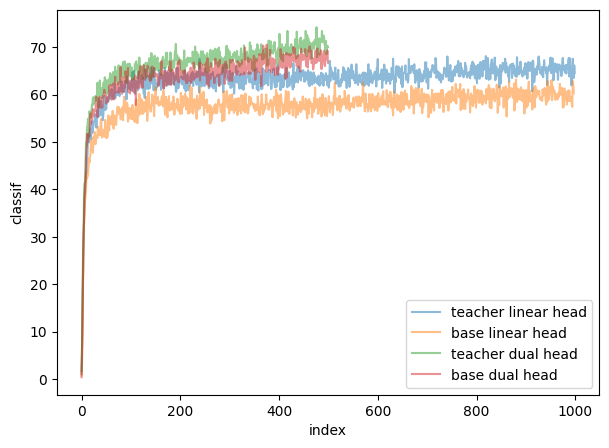

In [50]:
plt.figure(figsize=(7,
                    5))
sns.lineplot(teacher_linear_head_df, x='index', y='classif', label='teacher linear head', alpha = .5)
sns.lineplot(base_linear_head_df, x='index', y='classif', label='base linear head', alpha = .5)
sns.lineplot(teacher_dual_head_df, x='index', y='classif', label='teacher dual head', alpha = .5)
sns.lineplot(base_dual_head_df, x='index', y='classif', label='base dual head', alpha = .5)

plt.legend()

<Axes: xlabel='index', ylabel='classif'>

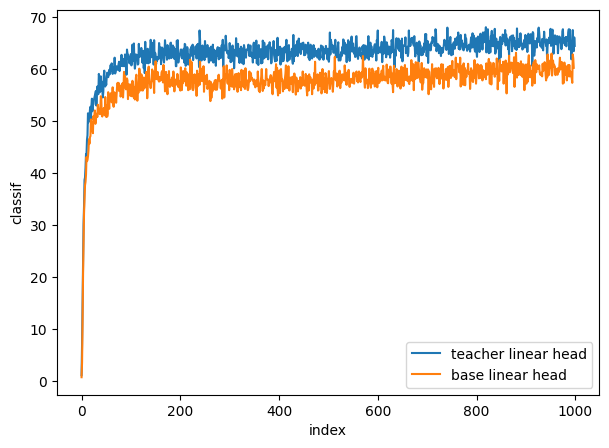